In [1]:
import pandas as pd
SAMPLES_PATH = '/usr2/people/macgregor/amplicon/test/data/merged/metadata/final_metadata.tsv'
# 1. Load the data
samples_df = pd.read_csv(SAMPLES_PATH, sep='\t', low_memory=False)
print(f"Initial shape: {samples_df.shape}")

# 2. First, handle NaN-to-None conversion for all OTHER property columns.
samples_df = samples_df.astype(object).where(pd.notna(samples_df), None)

# 3. NOW, perform the strict cleaning on the coordinate columns as the FINAL step.
samples_df['latitude_deg'] = pd.to_numeric(samples_df['latitude_deg'], errors='coerce')
samples_df['longitude_deg'] = pd.to_numeric(samples_df['longitude_deg'], errors='coerce')
samples_df.dropna(subset=['latitude_deg', 'longitude_deg'], inplace=True)
samples_df = samples_df[samples_df['latitude_deg'].between(-90, 90)]
samples_df = samples_df[samples_df['longitude_deg'].between(-180, 180)]
# 1. Reset the index. This creates a new, sequential index.
print("Resetting the index...")
samples_df.reset_index(inplace=True)
samples_df.drop(columns=['latitude_deg', 'longitude_deg'], inplace=True)
samples_df.rename(
    columns={'latitude_deg': 'latitude', 'longitude_deg': 'longitude'},
    inplace=True
)
cols_to_keep = [x for x in ['latitude', 'longitude', '#sampleid', 'dataset_name', 'env_biome', 'env_feature', 'env_material', 'collection_date', 'nuclear_contamination_status', 'facility_match', 'facility_distance_km'] if x in samples_df.columns]
samples_df = samples_df[cols_to_keep]
# 2. Immediately verify the result.
print("\n--- Verifying data AFTER resetting index ---")
samples_df.info()

Initial shape: (16766, 102)
Resetting the index...

--- Verifying data AFTER resetting index ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14511 entries, 0 to 14510
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   latitude                      8090 non-null   object
 1   longitude                     8090 non-null   object
 2   #sampleid                     14511 non-null  object
 3   dataset_name                  14244 non-null  object
 4   collection_date               11212 non-null  object
 5   nuclear_contamination_status  4911 non-null   object
 6   facility_match                14511 non-null  object
dtypes: object(7)
memory usage: 793.7+ KB


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_pie_chart(df, column_name):
  """
  Plots a pie chart of the composition of a DataFrame column.

  Args:
    df: The Pandas DataFrame.
    column_name: The name of the column to plot.
  """
  # Calculate the frequency of each category in the column
  value_counts = df[column_name].value_counts()

  # Create the pie chart
  plt.pie(value_counts, labels=value_counts.index, autopct='%1.1f%%')

  # Add a title
  plt.title(f'Composition of {column_name}')

  # Equal aspect ratio ensures that pie is drawn as a circle.
  plt.axis('equal')

  # Save the plot
  plt.savefig('pie_chart.png')

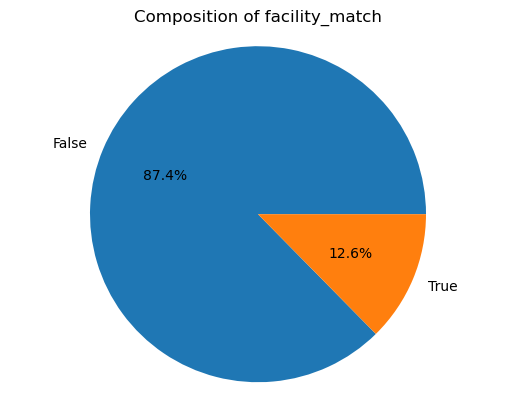

In [4]:
plot_pie_chart(samples_df, 'facility_match')